# Saving a strategy and applying it to a batch (Gating-ML 2.0)

The reason to model a gating strategy as an object that does not belong to any
one sample: **one strategy, ninety files**. This notebook saves a strategy, reads
it back, and runs it across a batch — and then does the thing that actually
matters, which is comparing the resulting frequencies across samples and noticing
where the strategy stopped fitting.

Continues from [gating](t_flow_02_gating.ipynb).

In [1]:
# The tutorials need no data of your own: this writes a small synthetic FCS 3.1
# file with known populations, a real $SPILLOVER keyword and a realistic noise
# floor (values around zero go negative, which is why a log axis will not do).
# It is written into the CURRENT WORKING DIRECTORY, as is strategy.xml later.
import numpy as np, pathlib, flowio

PANEL   = ["FSC-A","FSC-H","SSC-A","FITC-A","PE-A","PerCP-A","APC-A","Zombie-A"]
MARKERS = [None, None, None, "CD3", "CD4", "CD19", "CD8", "Viability"]
FLUORS  = ["FITC-A","PE-A","PerCP-A","APC-A"]
SPILL   = np.array([[1.00,0.18,0.06,0.01],
                    [0.03,1.00,0.11,0.01],
                    [0.01,0.04,1.00,0.14],
                    [0.00,0.01,0.03,1.00]])

def synthesise(seed=0):
    rng = np.random.default_rng(seed)
    def block(n, fsc, ssc, cd3, cd4, cd19, cd8, via, doublet=False):
        f = rng.normal(fsc, fsc*0.09, n)
        h = f/(1.85 if doublet else 1.0) + rng.normal(0, fsc*0.025, n)
        s = rng.normal(ssc, ssc*0.13, n)
        ch = lambda lv: rng.lognormal(np.log(lv), 0.42 if lv > 300 else 0.85, n)
        return (np.column_stack([f,h,s]),
                np.column_stack([ch(cd3),ch(cd4),ch(cd19),ch(cd8)]), ch(via))
    spec = [("debris",11000,17000,8500,25,22,20,24,55,False),
            ("CD4 T",17000,78000,24000,7500,9500,22,26,60,False),
            ("CD8 T",10000,76000,23000,8000,24,21,7000,58,False),
            ("DN T",1400,74000,22000,6500,26,23,28,62,False),
            ("DP T",500,79000,25000,7200,4200,22,3500,61,False),
            ("B",7500,82000,28000,28,25,6500,25,64,False),
            ("mono",5200,142000,58000,30,900,27,30,70,False),
            ("doublet",3800,80000,26000,6800,8200,24,27,60,True),
            ("dead",3200,76000,24000,5200,6000,30,26,7500,False)]
    sc, fl, vi, nm = [], [], [], []
    for name, n, *args in spec:
        s, f, v = block(n, *args)
        sc.append(s); fl.append(f); vi.append(v); nm.append(np.repeat(name, n))
    obs = np.vstack(fl) @ SPILL + rng.normal(0, 55, (sum(s.shape[0] for s in sc), 4))
    X = np.column_stack([np.vstack(sc), obs,
                         np.concatenate(vi) + rng.normal(0, 55, obs.shape[0])])
    perm = rng.permutation(X.shape[0])
    return X[perm], np.concatenate(nm)[perm]

def write_demo(path="flow_demo.fcs"):
    X, truth = synthesise()
    kw = ",".join([str(len(FLUORS))] + FLUORS + [f"{v:g}" for v in SPILL.ravel()])
    with open(path, "wb") as fh:
        flowio.create_fcs(fh, X.ravel().tolist(), channel_names=PANEL,
                          opt_channel_names=MARKERS,
                          metadata_dict={"SPILLOVER": kw, "CYT": "omicverse-demo"})
    return path, truth

path, truth = write_demo()
print(f"wrote {path} — {len(truth):,} events, {len(PANEL)} channels")


wrote flow_demo.fcs — 59,600 events, 8 channels


In [2]:
import omicverse as ov
import matplotlib.pyplot as plt

adata = ov.io.read_fcs("flow_demo.fcs")
adata.obs["truth"] = truth          # ground truth, only because this is synthetic
ov.flow.compensate(adata)

lin = ov.flow.Linear(t=262144.0)
lg  = ov.flow.Logicle(t=262144.0, m=4.5, w=1.0, a=0.0)
adata


/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 59600 × 8
    obs: 'sample', 'truth'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'meta', 'fcs', 'flow'
    layers: 'uncompensated'

In [3]:
def at(v):
    """A data value expressed on the logicle scale — how a threshold is really
    written. Typing 0.42 instead of at(600) is how gates drift."""
    return float(lg.apply(np.array([float(v)]))[0])

cells = ov.flow.PolygonGate(
    name="Cells", dims=("FSC-A", "SSC-A"),
    transforms={"FSC-A": lin, "SSC-A": lin},
    vertices=np.array([[0.12,0.01],[0.12,0.17],[0.40,0.32],
                       [0.68,0.32],[0.68,0.09],[0.38,0.01]]))
singlets = ov.flow.PolygonGate(
    name="Singlets", dims=("FSC-A", "FSC-H"),
    transforms={"FSC-A": lin, "FSC-H": lin},
    vertices=np.array([[0.05,0.03],[0.05,0.10],[0.75,0.86],[0.75,0.69]]))
live = ov.flow.RectangleGate(
    name="Live", dims=("Viability",), transforms={"Viability": lg},
    bounds=((None, at(1200)),))
cd3 = ov.flow.RectangleGate(
    name="CD3+", dims=("CD3",), transforms={"CD3": lg},
    bounds=((at(600), None),))
quad = ov.flow.QuadrantGate(
    name="CD4/CD8", dims=("CD4", "CD8"), transforms={"CD4": lg, "CD8": lg},
    dividers=(at(600), at(600)),
    quadrant_names=("DN", "CD4+CD8-", "CD4-CD8+", "DP"))

gs = ov.flow.GatingStrategy("T cell panel")
gs.add_gate(cells)
gs.add_gate(singlets, parent="Cells")
gs.add_gate(live,     parent="Singlets")
gs.add_gate(cd3,      parent="Live")
gs.add_gate(quad,     parent="CD3+")
print(gs.tree())


root
  └ Cells
    └ Singlets
      └ Live
        └ CD3+
          └ CD4/CD8
          └ DN
          └ CD4+CD8-
          └ CD4-CD8+
          └ DP


## Round-tripping through a dict

`to_dict` is JSON-able and is the seam a gate editor works against — a UI renders
and edits these dicts and never needs the Python objects.

In [4]:
import json

d = gs.to_dict()
print(json.dumps(d["gates"][3], indent=2)[:520], "...")

{
  "kind": "rectangle",
  "name": "CD3+",
  "dims": [
    "CD3"
  ],
  "transforms": {
    "CD3": {
      "type": "logicle",
      "t": 262144.0,
      "w": 1.0,
      "m": 4.5,
      "a": 0.0
    }
  },
  "bounds": [
    [
      0.34689636224578013,
      null
    ]
  ],
  "parent": "Live"
} ...


In [5]:
restored = ov.flow.GatingStrategy.from_dict(d)
print(restored)
print(restored.tree())

GatingStrategy('T cell panel', 5 gates)
root
  └ Cells
    └ Singlets
      └ Live
        └ CD3+
          └ CD4/CD8
          └ DN
          └ CD4+CD8-
          └ CD4-CD8+
          └ DP


The round trip has to preserve the *transforms*, not just the
geometry, or a restored gate lands somewhere else entirely. Check it rather than
assume it:

In [6]:
a = gs.apply(adata.copy())
b = restored.apply(adata.copy())
identical = all(np.array_equal(a.masks[k], b.masks[k]) for k in a.masks)
print(f"populations: {sorted(a.masks) == sorted(b.masks)}")
print(f"every mask identical after the round trip: {identical}")

populations: True
every mask identical after the round trip: True


## Gating-ML 2.0

The dict is convenient but omicverse-specific. **Gating-ML 2.0** is the ISAC
interchange standard, and it is what FlowJo, Cytobank and flowCore read.

In [7]:
ov.flow.write_gatingml(gs, "strategy.xml")
xml = pathlib.Path("strategy.xml").read_text()
print(f"{len(xml):,} bytes")
print(xml[:700], "...")

4,757 bytes
<?xml version='1.0' encoding='utf-8'?>
<ns0:Gating-ML xmlns:ns0="http://www.isac-net.org/std/Gating-ML/v2.0/gating" xmlns:ns1="http://www.isac-net.org/std/Gating-ML/v2.0/transformations" xmlns:ns2="http://www.isac-net.org/std/Gating-ML/v2.0/datatypes" xmlns:gating="http://www.isac-net.org/std/Gating-ML/v2.0/gating" xmlns:transforms="http://www.isac-net.org/std/Gating-ML/v2.0/transformations" xmlns:data-type="http://www.isac-net.org/std/Gating-ML/v2.0/datatypes">
  <ns1:transformation ns1:id="xf_FSC_negA_linear">
    <ns1:flin ns1:T="262144.0" ns1:A="0.0" />
  </ns1:transformation>
  <ns1:transformation ns1:id="xf_SSC_negA_linear">
    <ns1:flin ns1:T="262144.0" ns1:A="0.0" />
  </ns1:transfo ...


In [8]:
from_file = ov.flow.read_gatingml("strategy.xml")
c = from_file.apply(adata.copy())
print(from_file)
print("masks identical to the original:",
      all(np.array_equal(a.masks[k], c.masks[k]) for k in a.masks))

GatingStrategy('strategy', 5 gates)
masks identical to the original: True


## One strategy, several samples

Now the point of all of it. Three files with different biology — the second has
lost most of its CD4 compartment, the third is a lower-quality run — gated by
the *same* strategy object.

All three are **synthetic**: they are re-syntheses of the same simulated panel
with a population thinned, not real patients. The frequencies below are
therefore a demonstration of the mechanism and nothing else.

In [9]:
def variant(seed, cd4_scale=1.0, dead_scale=1.0, name="s"):
    """Re-synthesise with a perturbation, write it, read it back."""
    X, tr = synthesise(seed=seed)
    # thin the CD4 T compartment / inflate the dead fraction
    keep = np.ones(X.shape[0], bool)
    rng = np.random.default_rng(seed + 100)
    for pop, scale in (("CD4 T", cd4_scale), ("dead", dead_scale)):
        idx = np.flatnonzero(tr == pop)
        if scale < 1.0:
            drop = rng.choice(idx, size=int(len(idx) * (1 - scale)), replace=False)
            keep[drop] = False
    X, tr = X[keep], tr[keep]
    fn = f"{name}.fcs"
    kw = ",".join([str(len(FLUORS))] + FLUORS + [f"{v:g}" for v in SPILL.ravel()])
    with open(fn, "wb") as fh:
        flowio.create_fcs(fh, X.ravel().tolist(), channel_names=PANEL,
                          opt_channel_names=MARKERS,
                          metadata_dict={"SPILLOVER": kw})
    ad = ov.io.read_fcs(fn)
    ov.flow.compensate(ad)
    return ad

batch = {
    "healthy":     adata,
    "CD4-depleted": variant(1, cd4_scale=0.15, name="depleted"),
    "poor-quality": variant(2, cd4_scale=0.8, dead_scale=1.0, name="poor"),
}
{k: v.n_obs for k, v in batch.items()}

{'healthy': 59600, 'CD4-depleted': 45150, 'poor-quality': 56201}

In [10]:
import pandas as pd

rows = []
for name, sample in batch.items():
    r = gs.apply(sample.copy())
    s = r.stats().set_index("population")["freq_parent"]
    rows.append(s.rename(name))
freqs = pd.concat(rows, axis=1)
freqs.style.format("{:.1%}")

,healthy,CD4-depleted,poor-quality
population,,,
CD3+,69.5%,53.3%,66.8%
CD4+CD8-,58.8%,17.7%,53.3%
CD4-CD8+,34.6%,69.2%,39.2%
CD4/CD8,100.0%,100.0%,100.0%
Cells,81.5%,75.6%,80.4%
DN,4.8%,9.7%,5.5%
DP,1.7%,3.5%,2.0%
Live,92.8%,89.4%,92.2%
Singlets,92.2%,88.9%,91.6%


Easier to read as a picture — and this is the figure a batch
actually produces, one bar group per population, one colour per sample:

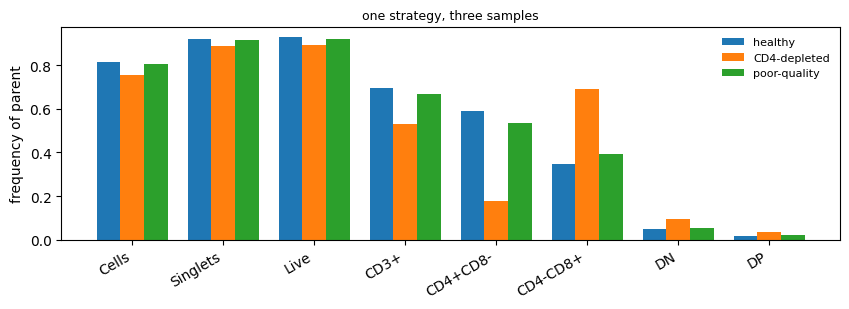

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 3.2))
order = ["Cells", "Singlets", "Live", "CD3+", "CD4+CD8-", "CD4-CD8+", "DN", "DP"]
sub = freqs.loc[order]
x, w = np.arange(len(order)), 0.26
for i, col in enumerate(sub.columns):
    ax.bar(x + (i - 1) * w, sub[col], w, label=col)
ax.set_xticks(x, labels=order, rotation=30, ha="right")
ax.set_ylabel("frequency of parent")
ax.set_title("one strategy, three samples", fontsize=9)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()

The CD4 depletion is unmissable in `CD4+CD8-` — and note that
`freq_parent` is what makes the comparison legitimate, since the three files do
not have the same number of events.

Side by side, on the same axes, with the same gate:

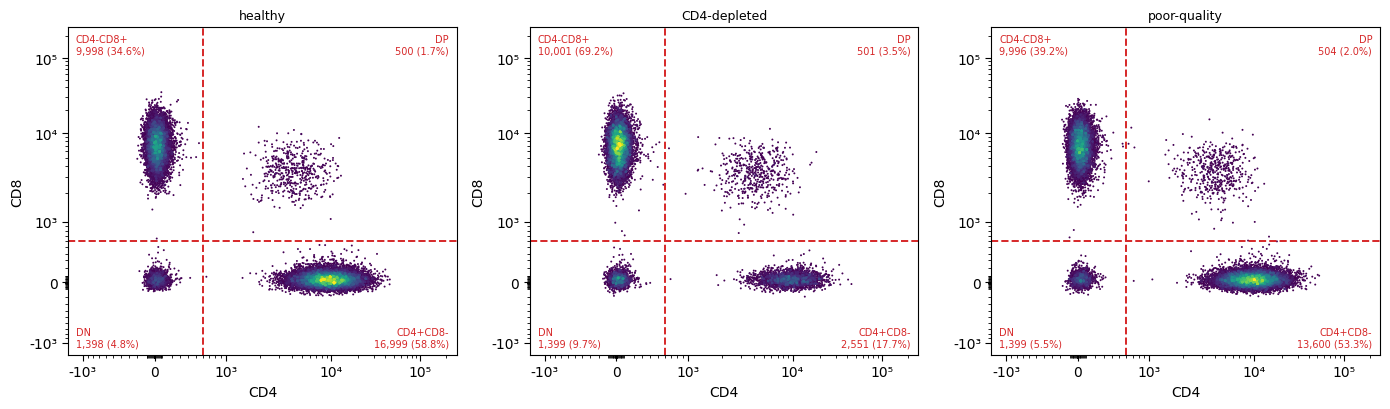

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, sample) in zip(axes, batch.items()):
    r = gs.apply(sample.copy())
    ov.flow.biaxial(sample, "CD4", "CD8", gates=[quad], result=r,
                    population="CD3+", ax=ax, max_events=30000,
                    title=name)
plt.tight_layout()

## Diffing two strategies

Because a strategy is data, two of them can be compared — which is the other
thing that is hard to do by hand. Here a colleague has tightened the **viability**
threshold, three nodes above the populations anyone will report:

In [13]:
theirs = ov.flow.GatingStrategy.from_dict(gs.to_dict())
theirs.name = "T cell panel (revised)"
theirs.gates["Live"].bounds = ((None, at(300)),)

mine   = gs.apply(adata.copy()).stats().set_index("population")["count"]
yours  = theirs.apply(adata.copy()).stats().set_index("population")["count"]
diff = pd.DataFrame({"original": mine, "revised": yours})
diff["delta"] = diff["revised"] - diff["original"]
diff["pct"] = (diff["delta"] / diff["original"]).map("{:+.1%}".format)
diff

            original  revised  delta    pct
population                                 
CD3+           28895    27954   -941  -3.3%
CD4+CD8-       16999    16453   -546  -3.2%
CD4-CD8+        9998     9674   -324  -3.2%
CD4/CD8        28895    27954   -941  -3.3%
Cells          48587    48587      0  +0.0%
DN              1398     1343    -55  -3.9%
DP               500      484    -16  -3.2%
Live           41574    40085  -1489  -3.6%
Singlets       44785    44785      0  +0.0%

One threshold, moved at a node nobody reports, and every population
below it changes. This is the argument for keeping the strategy as an object
that can be diffed rather than as a sequence of clicks: the number that moved is
not the one that was edited.

## What is next

Everything so far is manual and auditable. [The last
notebook](t_flow_04_flowsom.ipynb) adds unsupervised clustering — and is
explicit about what it does *not* replace.